In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from feature_engine.selection import MRMR
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


X = pd.read_csv("../dataset/o_shank.csv")
y = pd.read_csv("../dataset/distances.csv")["distance"][:X.shape[0]]

def plot_top_features(importance: pd.Series, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh", color="gray")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

--- Method (i): Correlation Ranking ---


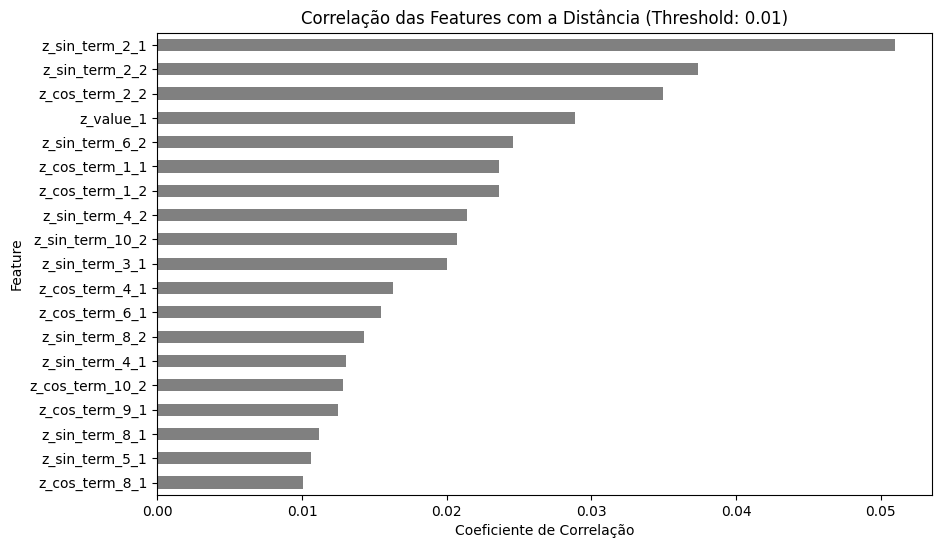

In [2]:
print("--- Method (i): Correlation Ranking ---")
correlations = X.corrwith(y)
threshold = 0.01
sorted_correlation_rank = correlations.abs().sort_values(ascending=False)
top_features = sorted_correlation_rank[sorted_correlation_rank > threshold]
plot_top_features(
    top_features,
    f"Correlação das Features com a Distância (Threshold: {threshold})",
    "Coeficiente de Correlação",
    "Feature"
)

--- Method (iii) Neural Network Importance Ranking ---


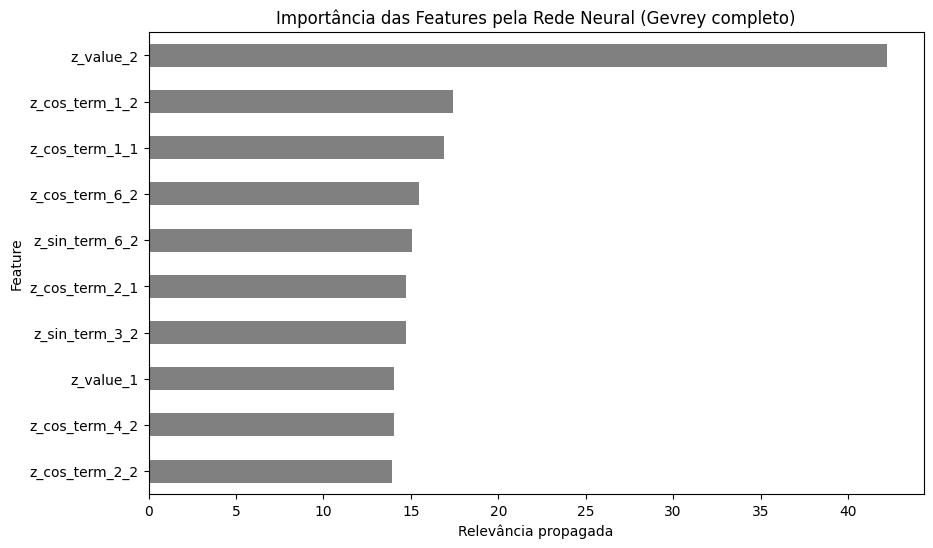

In [3]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("--- Method (iii) Neural Network Importance Ranking ---")
nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y)
weights = nn_model.coefs_
feature_relevance = np.abs(weights[0])

for i in range(1, len(weights)):
    feature_relevance = feature_relevance @ np.abs(weights[i])

feature_importance = feature_relevance.sum(axis=1)
nn_importance = pd.Series(feature_importance, index=X.columns)

threshold_nn = np.percentile(feature_importance, 75)

final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

plot_top_features(
    final_ranked_features,
    "Importância das Features pela Rede Neural (Gevrey completo)",
    "Relevância propagada",
    "Feature"
)

Testing with 10 features...
Testing with 20 features...
Testing with 30 features...
Testing with 40 features...


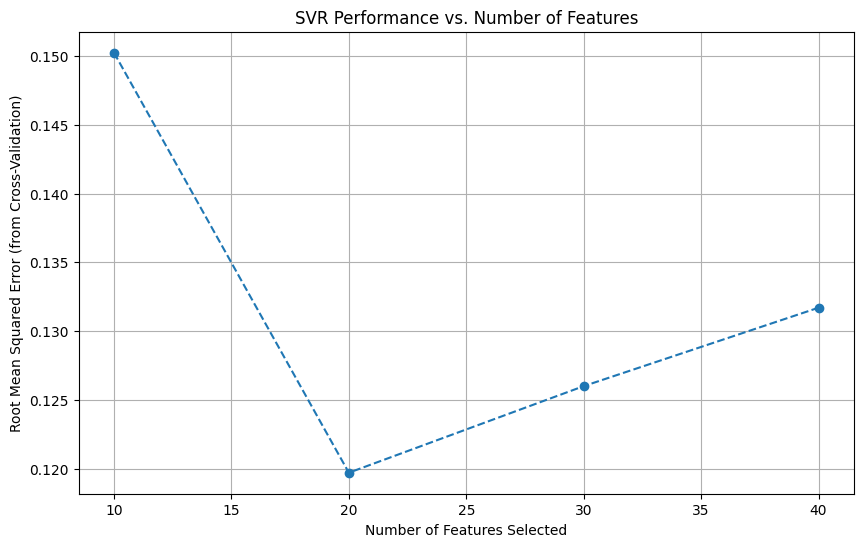


Optimal number of features for SVR: 20


In [4]:
n_features_to_test = np.arange(10, X.shape[1] + 1, 10)
cv_scores = []

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', SVR())
])

for n_features in n_features_to_test:
    print(f"Testing with {n_features} features...")
    mrmr_selector = MRMR(method="MID", regression=True, max_features=int(n_features))
    X_reduced = mrmr_selector.fit_transform(X, y)
    scores = cross_val_score(pipeline, X_reduced, y, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_scores.append(np.mean(scores))
    selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]

plt.figure(figsize=(10, 6))
plt.plot(n_features_to_test, [-s for s in cv_scores], marker='o', linestyle='--')
plt.xlabel("Number of Features Selected")
plt.ylabel("Root Mean Squared Error (from Cross-Validation)")
plt.title("SVR Performance vs. Number of Features")
plt.grid(True)
plt.show()

best_n_features = n_features_to_test[np.argmax(cv_scores)]
print(f"\nOptimal number of features for SVR: {best_n_features}")

---Evaluating SVR with 10 features---
---Evaluating MLP with 10 features---
---Evaluating MLP with 20 features---
---Evaluating SVR with 20 features---
---Evaluating MLP with 30 features---
---Evaluating SVR with 30 features---
---Evaluating MLP with 40 features---
---Evaluating SVR with 40 features---


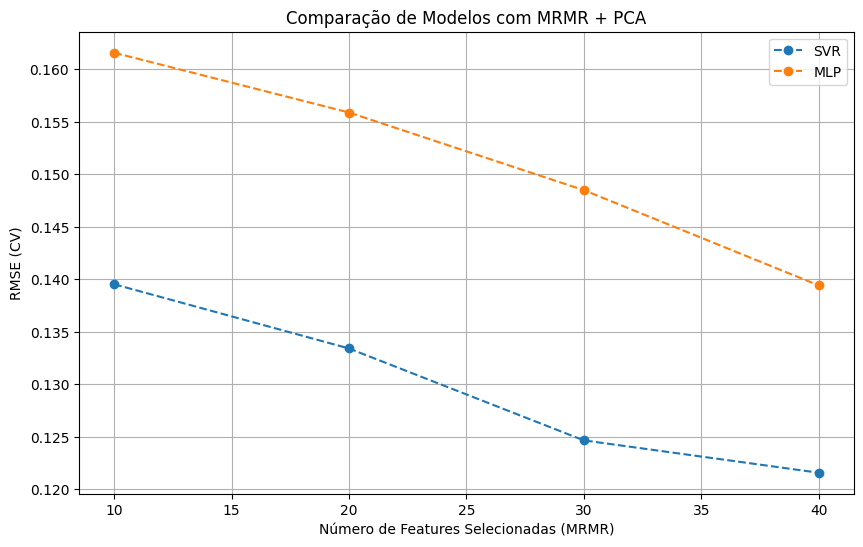

Melhor modelo: SVR
Melhor número de features (MRMR): 40
RMSE mínimo: 0.12155224667060005


In [5]:
from multiprocessing import Process, Manager
from sklearn.decomposition import PCA

n_features_to_test = np.arange(10, X.shape[1] + 1, 10)

models = {
    "SVR": SVR(),
    "MLP": MLPRegressor(hidden_layer_sizes=(34,34), max_iter=500, random_state=42)
}

def evaluate_model(model_name, model, X, y, n_features_to_test, return_dict):
    model_results = []
    model_best_features = {}
    pipeline = Pipeline([('scaler', MinMaxScaler()), ('model', model)])

    for n_features in n_features_to_test:
        print(f"---Evaluating {model_name} with {n_features} features---")
        mrmr_selector = MRMR(method="MID", regression=True, max_features=int(n_features))
        X_mrmr = mrmr_selector.fit_transform(X, y)
        selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
        model_best_features[n_features] = list(selected_features)

        pca = PCA(n_components=min(10, X_mrmr.shape[1]))
        X_pca = pca.fit_transform(X_mrmr)
 
        scores = cross_val_score(pipeline, X_pca, y, cv=10, scoring='neg_root_mean_squared_error', n_jobs=1)
        model_results.append(-np.mean(scores))
 
    return_dict[model_name] = (model_results, model_best_features)


manager = Manager()
return_dict = manager.dict()
processes = []

for name, model in models.items():
    p = Process(target=evaluate_model, args=(name, model, X, y, n_features_to_test, return_dict))
    p.start()
    processes.append(p)

for p in processes:
    p.join()

results = {k: return_dict[k][0] for k in models.keys()}
best_features_per_model = {k: return_dict[k][1] for k in models.keys()}

plt.figure(figsize=(10,6))
for name in models.keys():
    plt.plot(n_features_to_test, results[name], marker='o', linestyle='--', label=name)
plt.xlabel("Número de Features Selecionadas (MRMR)")
plt.ylabel("RMSE (CV)")
plt.title("Comparação de Modelos com MRMR + PCA")
plt.legend()
plt.grid(True)
plt.show()

best_model_name = min(results, key=lambda k: min(results[k]))
best_k_index = np.argmin(results[best_model_name])
best_k = n_features_to_test[best_k_index]

print("Melhor modelo:", best_model_name)
print("Melhor número de features (MRMR):", best_k)
print("RMSE mínimo:", results[best_model_name][best_k_index])

best_features_final = {"best_features": best_features_per_model[best_model_name][best_k]}
pd.DataFrame(best_features_final).to_csv("../results/best_features_experiment_6.csv", index=False)


In [6]:
n_features_mrmr = 10
mrmr_selector = MRMR(method="MID", regression=True, max_features=n_features_mrmr)
X_mrmr = mrmr_selector.fit_transform(X, y)

selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
pd.DataFrame({"selected_features": selected_features}).to_csv("../results/mrmr_selected_features_experiment_6.csv", index=False)